## 图像处理-2

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
def cv_show(img, name):
    cv2.imshow(name, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

```python
cv2.calcHist(images, channels, mask, histSize, ranges)
```
- images: 原图像格式为 uint8 或 float32. 当传入函数时，应用 [] 括起来
- channels: 如果传入的图是灰度图，他的值为[0]； 如果是彩色图像，则可以传入[0][1][2]，分别对应这 BGR
- mask: 掩膜图像。统计整幅图像的直方图就设为 None；但如果是统计图像莫一部分的直方图，就制作一个掩膜并使用他
- histSize: BIN 的数目。也应用中括号括起来
- ranges: 像素的范围常为：[0, 256]

In [ ]:
img = cv2.imread('figure.jpeg', 0)
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
hist.shape

(256, 1)

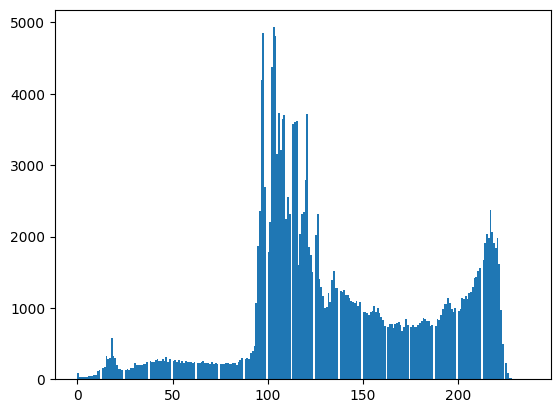

In [6]:
plt.hist(img.ravel(), 256)
plt.show()

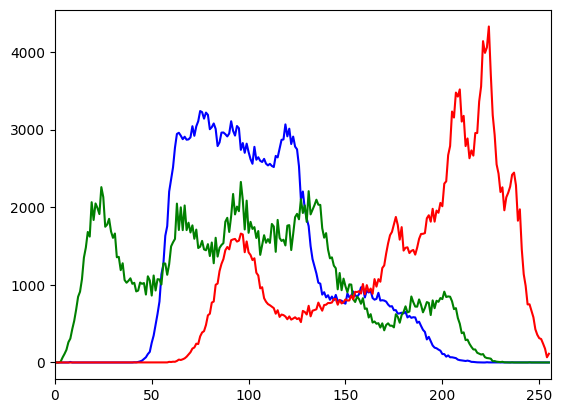

In [5]:
img = cv2.imread('lena.png')
color = ('b', 'g', 'r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(histr, color=col)
    plt.xlim([0,256])

### mask 操作

In [6]:
# 创建 mask
mask = np.zeros(img.shape[:2], np.uint8)
mask[100:300, 100:400] = 255
cv_show(mask, 'mask')

In [7]:
img = cv2.imread('lena.png', 0)
cv_show(img, 'img')

In [8]:
masked_img = cv2.bitwise_and(img, img, mask=mask) # 与操作
cv_show(masked_img, 'masked_img')

In [11]:
hist_full = cv2.calcHist([img], [0], None, [256], [0,256])
hist_mask = cv2.calcHist([img], [0], mask, [256], [0,256])

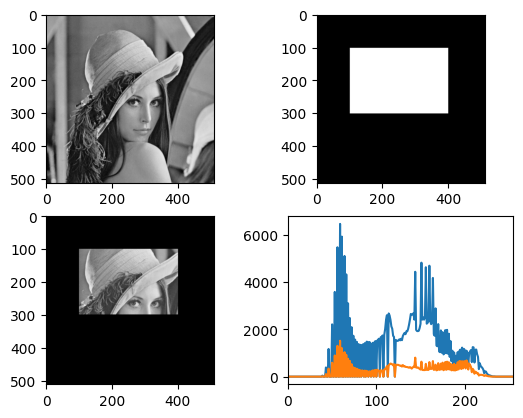

In [12]:
plt.subplot(221), plt.imshow(img, 'gray')
plt.subplot(222), plt.imshow(mask, 'gray')
plt.subplot(223), plt.imshow(masked_img, 'gray')
plt.subplot(224), plt.plot(hist_full), plt.plot(hist_mask)
plt.xlim([0,255])
plt.show()

### 直方图均衡化

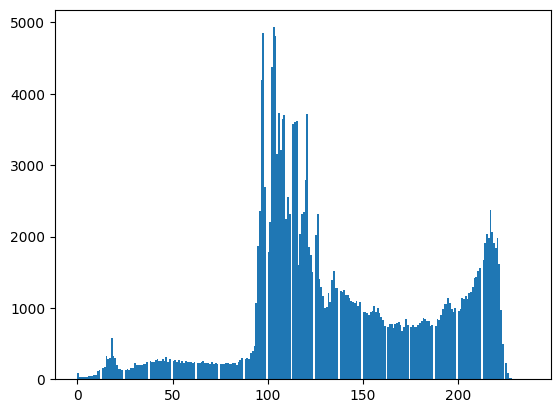

In [3]:
img = cv2.imread('figure.jpeg', 0)
plt.hist(img.ravel(), 256)
plt.show()

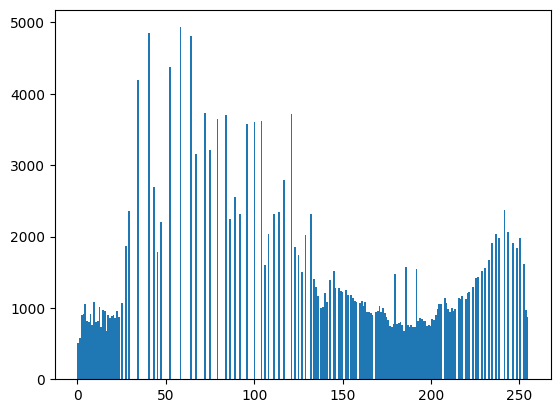

In [4]:
equ = cv2.equalizeHist(img)
plt.hist(equ.ravel(), 256)
plt.show()

In [7]:
res = np.hstack((img, equ))
cv_show(res, 'res')

### 自适应直方图均衡化

In [2]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

In [8]:
res_clahe = clahe.apply(img)
res = np.hstack((img, equ, res_clahe))
cv_show(res, 'res')

## 傅里叶变换
- 高频：变换剧烈的灰度分量，例如边界
- 低频：变换缓慢的灰度分量

## 滤波
- 低通滤波器：只保留低频，会使图像模糊
- 高频滤波器：只保留高频，会使得图像的细节增强

- opencv 中主要就是 cv2.dft() 和 cv2.idft()，输入图像需要先转换成 np.float32格式
- 得到的结果中频率为0的部分会在左上角，通常要转换到中心的位置，可以通过shift变换来实现
- cv2.dft()返回的结果是双通道的（实部，虚部），通常还需要转换成图像格式才能展示（0,255）

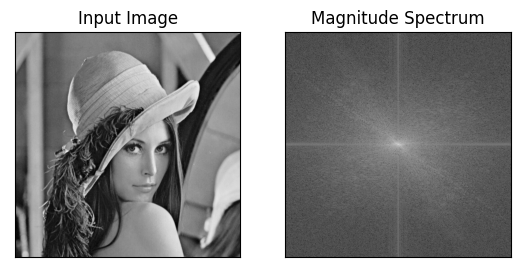

In [9]:
img = cv2.imread('lena.png', 0)

img_float32 = np.float32(img)

dft = cv2.dft(img_float32, flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# 得到灰度图能表示的形式
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum"), plt.xticks([]), plt.yticks([])
plt.show()

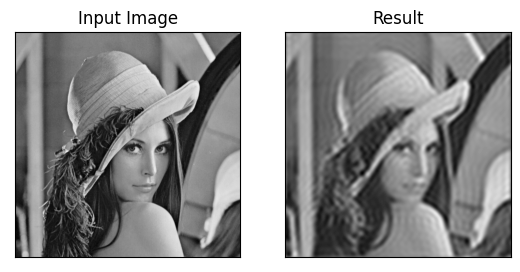

In [ ]:
img = cv2.imread('lena.png', 0)
img_float32 = np.float32(img)

dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = int(rows/2), int(cols/2)

# 低通滤波
mask = np.zeros((rows, cols, 2), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# IDFT
fshift = dft_shift*mask
f_shift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_shift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Result'), plt.xticks([]), plt.yticks([])
plt.show()

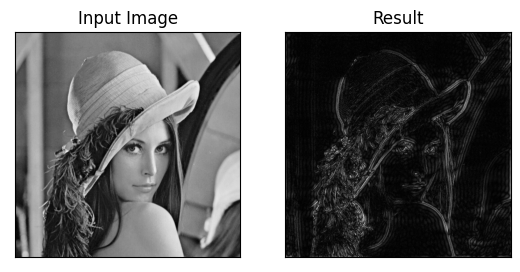

In [11]:
img = cv2.imread('lena.png', 0)
img_float32 = np.float32(img)

dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img.shape
crow, ccol = int(rows/2), int(cols/2)

# 高通滤波
mask = np.ones((rows, cols, 2), np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 0

# IDFT
fshift = dft_shift*mask
f_shift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_shift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(img_back, cmap='gray')
plt.title('Result'), plt.xticks([]), plt.yticks([])
plt.show()